# Tasks
• One-hot encode at least 2 categorical columns using pd.get_dummies()

• Ordinal encode 1 ordered column (e.g., quality: low → high)

• Scale at least 2 numerical columns using StandardScaler

• Create 2 domain features: a meaningful ratio (e.g., price_per_sqft) and one more of your choice.
Use safe division to avoid dividing by zero

• Create 1 interaction feature: multiply two columns that logically go together (e.g., quality × area)

• Log-transform 1 skewed column using np.log1p() — show the histogram before and after

• Bin 1 column into meaningful groups (e.g., age groups: New, Recent, Old)

• Remove redundant features: find highly correlated pairs (r > 0.95) and drop one

In [113]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
#Loading the new csv
df = pd.read_csv("titanic_cleaned.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [115]:
#Checking the csv
print(df.shape)
df.info()

(891, 11)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [116]:
#Great, now we can start on the first task: 
#One-hot encode at least 2 categorical columns using pd.get_dummies()
#For this task, the only two categorical columns that can be used (i.e Nominal) are Sex and Embarked

In [117]:
df_ohe = pd.get_dummies(df, columns=["Sex", "Embarked"], prefix=["Sex", "Embarked"])
df_ohe.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,False,True,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,65.6344,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,True,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,False,True,False,False,True


In [118]:
#Now, for Ordinal Encoding we can use 'Pclass', an ordinal variable, due to its obvious hierarchy (1>2>3)
Pclass_ord = pd.CategoricalDtype(
categories=[3, 2, 1], ordered=True)
df_ohe["Pclass_ord"] = df_ohe["Pclass"].astype(Pclass_ord).cat.codes + 1 # +1 so that the Interaction on cell 10 doesn't result in 0 for some outputs
#And to make it cleaner, I'll drop the 'Pclass'
df_ohe = df_ohe.drop(columns = ["Pclass"])
df_ohe.head()

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_ord
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,False,True,False,False,True,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,65.6344,True,False,True,False,False,3
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,True,False,False,False,True,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,True,False,False,False,True,3
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,False,True,False,False,True,1


In [119]:
#Now we scale at least 2 numerical columns using StandardScaler
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
#Let's make a copy of the DataFrame, just incase something goes wrong!
df_std = df_ohe.copy()
#And now we use StandardScaler
df_std[["Age_std", "Fare_std"]] = std_scaler.fit_transform(df_ohe[["Age", "Fare"]])
#Verify
print(df_std[["Age_std", "Fare_std"]].agg(["mean", "std"]))
#Output first five rows, why not?
df_std.head()

           Age_std      Fare_std
mean  2.272780e-16  9.968332e-17
std   1.000562e+00  1.000562e+00


,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_ord,Age_std,Fare_std
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,False,True,False,False,True,1,-0.565736,-0.820552
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,65.6344,True,False,True,False,False,3,0.663861,2.031623
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,True,False,False,False,True,1,-0.258337,-0.787578
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,True,False,False,False,True,3,0.433312,1.419297
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,False,True,False,False,True,1,0.433312,-0.781471


In [120]:
#Now we make domain features

#Ratio Domain
# family_size: represents the number of family members traveling with the passenger.
# Larger families may behave differently during evacuation.
df_std["family_size"] = df_std["SibSp"] + df_std["Parch"] + 1
#With this domain, we can now make the ratio
# fare_per_person: represents ticket cost per traveler within a family group.
# This normalizes fare differences for passengers traveling together.
df_std["fare_per_person"] = df_std["Fare"] / df_std["family_size"].replace(0, np.nan)
#Additional meaningful domain
# is_alone: indicates whether the passenger traveled alone, which may affect survival behavior.
df_std["is_alone"] = (df_std["family_size"] == 1).astype(int)

#To make sure
df_std[["family_size", "fare_per_person", "is_alone"]].head()

,family_size,fare_per_person,is_alone
0,2,3.6250,0
1,2,32.8172,0
2,1,7.9250,1
3,2,26.5500,0
4,1,8.0500,1


In [121]:
#For Interaction, I'll make an Interaction between Pclass and Fare, because they both are linked to eachother.
#I'll use Pclass_ord and fare_per_person, because they don't count the Fare for the whole family and as for 
#Pclass_ord it is more logical than Pclass because someone in class3 would be higher than someone in 1 
#during the interaction.
df_std["Pclass_Fare"] = df_std["Pclass_ord"] * (df_std["fare_per_person"])
#checking
df_std.head()

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_ord,Age_std,Fare_std,family_size,fare_per_person,is_alone,Pclass_Fare
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,False,True,False,False,True,1,-0.565736,-0.820552,2,3.6250,0,3.6250
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,65.6344,True,False,True,False,False,3,0.663861,2.031623,2,32.8172,0,98.4516
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,True,False,False,False,True,1,-0.258337,-0.787578,1,7.9250,1,7.9250
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,True,False,False,False,True,3,0.433312,1.419297,2,26.5500,0,79.6500
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,False,True,False,False,True,1,0.433312,-0.781471,1,8.0500,1,8.0500


np.float64(1.082178592000912)

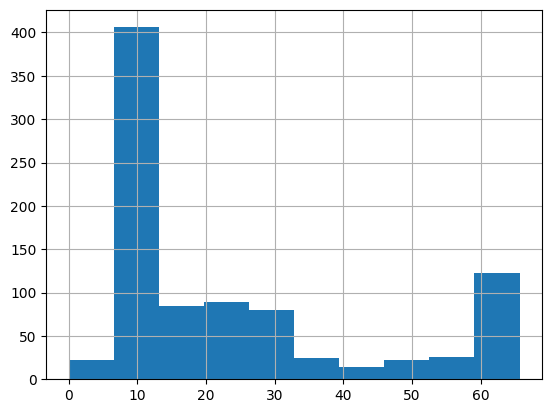

In [122]:
#Now for transforming a skewed column.
df_std["Fare"].hist()
df_std["Fare"].skew()

np.float64(-0.2378769041514196)

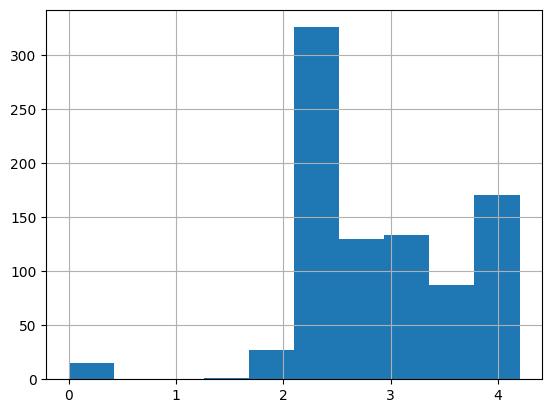

In [123]:
#Now that is a heavily skewed column!
#Let's transform it
df_std["Fare_transformed"] = np.log1p(df_std["Fare"])
df_std["Fare_transformed"].hist()
df_std["Fare_transformed"].skew()

In [124]:
#Great! Now, time for binning. I will copy the code from the course's Day 18 Binning Equal Width
bin_edges = [0, 18, 35, 50, 100]
labels = ["Child", "YoungAdult", "Adult", "Senior"]
df_std["age_bins_width"] = pd.cut(df_std["Age"], bins=bin_edges, labels=labels, right=False)
print(df_std["age_bins_width"].value_counts())

age_bins_width
YoungAdult    543
Adult         161
Child         113
Senior         74
Name: count, dtype: int64


In [125]:
# Finally! we can now remove redundant features and finish this phase to go to the next.
def drop_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr(numeric_only=True).abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop
#Let's run the function
df_final, dropped_cols = drop_correlated_features(df_std)

print("Dropped columns:", dropped_cols)
print("New shape:", df_final.shape)

Dropped columns: ['Sex_male', 'Age_std', 'Fare_std', 'Pclass_Fare']
New shape: (891, 18)


In [126]:
#Let's move our cleaned DataFrame to a new csv, so that we can use it in the next phases
df_final.to_csv("titanic_features.csv", index=False)